# Calculate product footprints and generate hotspot figure

## Notebook README

**Related publication**

If you utilize any portions of the code, results, or draw inspiration for your projects, please give proper credit by citing the published article below.

 - Title: Residual biomass to bio-based chemicals and plastics: ex-ante screening methodology for prioritizing high-impact substitutions
 - Authors: [Nicolas LIENART](https://orcid.org/0009-0001-3259-2819), [Thibaut LECOMPTE](https://orcid.org/0000-0001-9237-8454), [Lorie HAMELIN](https://orcid.org/0000-0001-9092-1900) 
 - Journal: Resources, Conservation and Recycling (RCR) - Elsevier
 - Doi: #todo
 - Code author: Nicolas LIENART
 - Git repository (Forge INRAE): https://forge.inrae.fr/nicolas.lienart/screen-lca-paper-supplementary-code
 - Git repository (GitHub): https://github.com/nicolnt/screen-lca-paper-supplementary-code

**Description and details**

This code generates the hotspot figure (Figure 2) showing the import and production amount of chemicals and plastics in the EU27, their unit GHG footprint (cradle-to-gate), the total estimated footprint (cradle-to-gate) and the estimated end of life impacts. Refer to the aforementioned main manuscript and accompanying supplementary information documents for more details.

**Updates**

 - May 04, 2026: Ready for submission
 - August 11, 2026: Refactor code. Add support for multiple Ecoinvent database version. Split activities in multiple regions. Removed check in the function for substances LCA that could prevent further recursive calls despite behing possibly relevants.
 - August 12, 2026: Refactor code. Fixed an error in the end-of-life footprint calculation where C was not converted to CO2. Calculate footprint share due to imports and show in the figure.
 - August 14, 2026: Refactor code. Improve figure rendering for readability and bring additional informations.
 - August 14, 2026: Extract Ecoinvent database code to a common module.
 - August 15, 2026: Update figure output code for easier change of Ecoinvent database version.

**Package versions**

 - See [`environment.yml`](./environment.yml)

**Relevant references**

ChatGPT was used to help with the SVG post-treatment.

- Prompts:
  - `Using matplotlib, I want to export the figure as a svg. But instead of each bars of each plt.bar having a name as "patch_xx" and containing "pathxx", where xx are digits, I want it to have meaningful names, based on dataframe data and index. How shoul I proceed?`
  - `How can I put all bars in "ax.bar" in a same parent svg group, also named.`
  - `This does not work, I get the following error: AttributeError: 'BarContainer' object has no attribute 'set_gid'`
  - `How can I make pyplot to stop putting single paths in groups when exporting to svg?`
  - `Using XPath syntax, how do I select all groups that are in the group with id="hello"`
- Public link: https://chatgpt.com/share/693bf85f-d4bc-8009-9538-189cdfdd7e83

**Licence**

This work is licenced under the Creative Commons Attribution (CC-BY 4.0) public licence.

## Initialization

### Python imports

In [7]:
import bw2data as bd
import bw2io as bi
import bw2calc as bc
import pandas as pd
import numpy as np
import re
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from importlib.metadata import version

20:00:45+0200 [warning  ] Can't import `SimaProBlockCSVImporter` - please install `bw2io` with `pip install bw2io[multifunctional]` or install `multifunctional` and `bw_simapro_csv` manually.


In [8]:
print('bw2data:', version('bw2data'), "commit:", "532e73e8eb86668ba07a5378279ca33c74f76990")
print('bw2io:', version('bw2io'))
print('bw2calc:', version('bw2calc'))
print('pandas:', version('pandas'))
print('numpy:', version('numpy'))
print('matplotlib:', version('matplotlib'))

bw2data: 4.7 commit: 532e73e8eb86668ba07a5378279ca33c74f76990
bw2io: 0.9.17
bw2calc: 2.4.0
pandas: 2.2.3
numpy: 2.4.3
matplotlib: 3.10.9


### Import some global variables from file

Your `.env` file is a collection of key-value pairs, separated by a `=` sign. It should contain these lines with the relevant values:

```bash
ecoinvent_username="replace_with your Ecoinvent's licence username"
ecoinvent_password="replace_with your Ecoinvent's licence password"
project_name="replace with project name"
```

We can then access this information with the dotenv and Python's built-in `os` libraries.

In [9]:
import os
from dotenv import load_dotenv  # To read the contents of the .env file

load_dotenv(override=True)

# NOTE: Get Ecoinvent account login details from a different file
ECOINVENT_USERNAME = os.getenv("ecoinvent_username")
ECOINVENT_PASSWORD = os.getenv("ecoinvent_password")

BW_PROJECT_NAME = os.getenv("project_name")

In [ ]:
# NOTE: Manually set Brightway current project
# PROJECT_NAME = "a-brightway-project"

### Manually set other global variables

In [10]:
UNIT_EOL_FOOTPRINT_COLUMN_NAME = 'Unit impact of end-of-life (kg CO2/kg)'
UNIT_FOOTPRINT_WITHOUT_EOL_COLUMN_NAME = "Unit GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg)"
UNIT_FOOTPRINT_WITH_EOL_COLUMN_NAME = "Unit GHG footprint with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)"
TOTAL_FOOTPRINT_WITHOUT_EOL_COLUMN_NAME = "Total GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg)"
TOTAL_FOOTPRINT_WITH_EOL_COLUMN_NAME = "Total GHG footprint with end-of-life (IPCC 2021 GWP100, kg CO2e/kg)"
QUANTITY_COLUMN_NAME = "Quantity (Mt/yr)"
UNIT_BTX_FOOTPRINT_COLUMN_NAME = "Unit GHG footprint of BTX (IPCC 2021 GWP100, kg CO2e/kg)"
OUTPUT_PRODUCT_CODE_COLUMN_NAME = "Total footprint rank"
ECOINVENT_ACTIVITY_COLUMN_NAME = "Ecoinvent activity name or proxy"
UNIT_FOOTPRINT_LOCAL_PRODUCTION_COLUMN_NAME = "Unit GHG footprint of local production share (IPCC 2021 GWP100, kg CO2e/kg)"
LOCAL_PRODUCTION_SHARE_COLUMN_NAME = "Local production share of available quantity (%)"

In [46]:
FIGURE_N_TOP_HOTSPOT_PRODUCTS = 15

In [12]:
# NOTE: Name corresponds to Ecoinvent's product name
SUBSTANCE_LIST = [
    {
        "name":'propylene',
        "CAS":'115-07-1'
    },
    {
        "name":'ethylene',
        "CAS":'74-85-1'
    },
    {
        "name":'methanol',
        "CAS":'000067-56-1'
    },
    {
        "name":'xylene, mixed',
        "CAS":'',
        "type": "BTX"
    },
    {
        "name":'o-xylene',
        "CAS":'95-47-6',
        "type": "BTX"
    },
    {
        "name":'p-xylene',
        "CAS":'106-42-3',
        "type": "BTX"
    },
    {
        "name":'toluene, liquid',
        "CAS":'108-88-3',
        "type": "BTX"
    },
    {
        "name":'benzene',
        "CAS":'000071-43-2',
        "type": "BTX"
    }
]

In [14]:
# NOTE: Local import
from py_utils import ecoinvent_databases

ECOINVENT_DATABASE_NAMES = ['ecoinvent-3.11-cutoff', 'ecoinvent-3.12-cutoff']
ECOINVENT_DATABASES = ecoinvent_databases.get_ecoinvent_databases(ECOINVENT_DATABASE_NAMES, project_name=BW_PROJECT_NAME)

### Additional settings

In [15]:
pd.options.display.max_columns = 100
pd.options.display.max_rows = 5

## Setup Brightway project

In [ ]:
# NOTE: List Brightway projects
sorted(bd.projects)

In [16]:
# NOTE: Select the brightway project to use for this notebook
bd.projects.set_current(name=BW_PROJECT_NAME)
# bd.projects.set_current(name="template-ecoinvent-3.11-consequential")
bd.projects.current

'20260809-paper-1-screen-lca'

### Import Ecoinvent (required only once per project and Ecoinvent database version)

In [ ]:
# NOTE: Download and load ecoinvent into the current project. Takes several minutes to complete.
bi.import_ecoinvent_release(
    version='3.12',
    system_model='cutoff',
    username=ECOINVENT_USERNAME, 
    password=ECOINVENT_PASSWORD 
)

In [16]:
# NOTE: List available databases in the current Brightway project
bd.databases

Databases dictionary with 4 object(s):
	ecoinvent-3.11-biosphere
	ecoinvent-3.11-cutoff
	ecoinvent-3.12-biosphere
	ecoinvent-3.12-cutoff

## General footprint calculation functions

In [17]:
def ecoinvent_region_and_share_series_to_df(ecoinvent_region_data):

    location_index = ecoinvent_region_data.loc[ecoinvent_region_data.index.str.endswith('location')].index.values

    # NOTE: Extract the part of the name that is common to use as index
    ecoinvent_region_index = [re.split(r"(^.*region \d)", s)[1] for s in location_index]            

    # NOTE: Construct the dataframe
    return pd.DataFrame([
            ecoinvent_region_data.loc[ecoinvent_region_data.index.str.endswith('location')].values,
            ecoinvent_region_data.loc[ecoinvent_region_data.index.str.endswith('share')].values
        ], index=['location', 'share'], columns=ecoinvent_region_index).T

In [18]:
# NOTE: calculate LCA score for a product by reusing a pre-calculated Brightway LCA object
def calculate_LCA(code=None, id=None, ecoinvent_version: str = 'ecoinvent-3.11-cutoff', amount=1):
    ecoinvent_database_dict = ECOINVENT_DATABASES[ecoinvent_version]

    if id is None:
        activity_id = ecoinvent_database_dict["db"].get(code).id
    else:
        activity_id = id
    
    # NOTE: Reuse the LCA object created before.
    # Source: https://github.com/brightway-lca/brightway2/blob/master/notebooks/Using%20redo_lci%20and%20redo_lcia.ipynb
    ecoinvent_database_dict["lca"].lcia(demand={activity_id: amount})
    return ecoinvent_database_dict["lca"].score

In [19]:
# NOTE: calculate LCA score for a product by reusing a pre-calculated Brightway LCA object
# Source : 13-08-2026 - https://claude.ai/share/37e61aa6-5b64-449a-b015-6ec4caf7c36e
def calculate_LCA_optimized(activity_id=None, ecoinvent_version: str = 'ecoinvent-3.11-cutoff', amount=1):
    ecoinvent_database_dict = ECOINVENT_DATABASES[ecoinvent_version]

    ecoinvent_database_dict["lca"].build_demand_array({activity_id: amount})
    supply = ecoinvent_database_dict["lca"].solve_linear_system() 
    score = ecoinvent_database_dict["h"] @ (ecoinvent_database_dict["lca"].biosphere_matrix @ supply)
    return score

In [20]:
def lca_contribution_of_substance_approach_1(activity_id, substance, recursive_call_left,
                                  ecoinvent_version: str = 'ecoinvent-3.11-cutoff', cutoff=1):

    activity = bd.get_activity(activity_id)
    
    # NOTE: Reached the end of the recursive path, don't go further.
    if recursive_call_left == 0:
        return 0
    
    else:
        activity_score = 0
        for exchange in activity.technosphere():

            exchange_id = exchange.input.id
            exchange_amount = exchange['amount']

            # NOTE: Assuming everything would be accounted as kg
            if exchange['unit'] != 'kilogram':
                continue

            
            # NOTE: Optimisation: Check if activity ISIC code is != than '19', '20', '21', '22'.
            # Assuming other type of activities won't deliver the substances.
            # See: https://ilostat.ilo.org/methods/concepts-and-definitions/classification-economic-activities/
            # 19 Manufacture of coke and refined petroleum products
            # 20 Manufacture of chemicals and chemical products
            # 21 Manufacture of basic pharmaceutical products and pharmaceutical preparations
            # 22 Manufacture of rubber and plastics products
            isic_code = ''
            if 'classifications' in exchange.input and len([e for e in exchange.input['classifications'] if e[0] == 'ISIC rev.4 ecoinvent']) > 0:
                isic_code = [e for e in exchange.input['classifications'] if e[0] == 'ISIC rev.4 ecoinvent'][0][1]
                # NOTE: Check the first two digits of ISIC classification and skip if other code is used
                if isic_code == '' or isic_code[0:2] not in ['19', '20', '21', '22']:
                    continue

            # NOTE: Optimisation: Apply a cutoff on the mass
            share = exchange['amount'] / activity['production amount']
            if share < cutoff:
                continue

            # NOTE: If CAS or name is matched, calculate and return footprint and stop there.
            if ('CAS number' in exchange and exchange['CAS number'] == substance['CAS']) \
                or exchange['name'].lower() == substance['name'].lower():
                activity_score += calculate_LCA_optimized(activity_id=exchange_id,
                                                ecoinvent_version=ecoinvent_version,
                                                amount=exchange_amount)
            else:
                exchange_score = exchange_amount * lca_contribution_of_substance_approach_1(activity_id=exchange_id,
                                                                                    substance=substance,
                                                                                    recursive_call_left=(recursive_call_left-1),
                                                                                    cutoff=cutoff * (1/share),
                                                                                    ecoinvent_version=ecoinvent_version)
                
                activity_score += exchange_score

        return activity_score

In [21]:
def lca_contribution_of_substance_approach_2(activity_id, total_footprint, substance, recursive_call_left,
                                  ecoinvent_version: str = 'ecoinvent-3.11-cutoff', cutoff=1, scaling_factor=1):

    activity = bd.get_activity(activity_id)

    # NOTE: Reached the end of the recursive path, don't go further.
    recursive_call_left -= 1
    if recursive_call_left <= -1:
        return (0, 0)
    
    else:
        activity_score = 0
        activity_substance_amount = 0

        for exchange in activity.technosphere():

            exchange_code = exchange['input'][1]
            exchange_amount = exchange['amount']

            absolute_exchange_amount = exchange_amount * scaling_factor

            # NOTE: Skip as exchange amount is below the cutoff
            if absolute_exchange_amount < cutoff:
                continue

            absolute_exchange_lca_score = calculate_LCA(id=exchange.input.id,
                                        ecoinvent_version=ecoinvent_version,
                                        amount=absolute_exchange_amount)

            absolute_exchange_lca_score_share = absolute_exchange_lca_score / total_footprint
            # NOTE: Skip as exchange footprint is below the cutoff
            if absolute_exchange_lca_score_share < cutoff:
                continue

            # NOTE: Optimisation: Check if activity ISIC code is != than '19', '20', '21', '22'
            # See: https://ilostat.ilo.org/methods/concepts-and-definitions/classification-economic-activities/
            # 19 Manufacture of coke and refined petroleum products
            # 20 Manufacture of chemicals and chemical products
            # 21 Manufacture of basic pharmaceutical products and pharmaceutical preparations
            # 22 Manufacture of rubber and plastics products
            isic_code = ''
            if 'classifications' in exchange.input:
                isic_code_list = [e for e in exchange.input['classifications'] if e[0] == 'ISIC rev.4 ecoinvent']
                if len(isic_code_list) > 0:
                    isic_code = isic_code_list[0][1]
                    # NOTE: Check the first two digits of ISIC classification and skip if other code is used
                    if len(isic_code)>2 and isic_code[0:2] not in ['19', '20', '21', '22']:
                        continue

            # NOTE: If CAS or name is matched, calculate and return footprint and stop there.
            if (exchange.get('CAS number') == substance['CAS']) or exchange['name'].lower() == substance['name'].lower():
                activity_score += absolute_exchange_lca_score
                activity_substance_amount += absolute_exchange_amount
                
            else:
                absolute_exchange_lca_score, exchange_substance_amount = lca_contribution_of_substance_approach_2(activity_id=exchange.input.id,
                                                                                    substance=substance,
                                                                                    total_footprint=total_footprint,
                                                                                    recursive_call_left=recursive_call_left,
                                                                                    cutoff=cutoff,
                                                                                    ecoinvent_version=ecoinvent_version,
                                                                                    scaling_factor=absolute_exchange_amount)
                
                activity_score += absolute_exchange_lca_score
                activity_substance_amount += exchange_substance_amount

        return (activity_score, activity_substance_amount)
        

In [22]:
def get_activity_by_name_location_priority(name, location_priority = ['RER', 'GLO', 'RoW'], ecoinvent_version: str = 'ecoinvent-3.12-cutoff'):
    activities = [a for a in ECOINVENT_DATABASES[ecoinvent_version]["db"].search(name) if a['name'] == name]
    
    if len(activities) > 0:
        for location in location_priority:
            activities_location = [a for a in activities if a['location'] == location]
            if len(activities_location):
                return activities_location[0]

        # NOTE: Select any location (region)
        # Situation not encountered with this case study, dataset always existed for either of 'RER', 'GLO' or 'RoW'    
        return activities.random() 

    else:
        return None

In [23]:
def get_activity_by_name_specific_location(name, location, ecoinvent_version: str = 'ecoinvent-3.12-cutoff'):
    activities = [a for a in ECOINVENT_DATABASES[ecoinvent_version]["db"].search(name) if a['name'] == name]
    
    if len(activities) > 0:
        activities_location = [a for a in activities if a['location'] == location]
        if len(activities_location):
            return activities_location[0]
        else:
            return "Location not found"

    else:
        return "Activity not found"

## Import Prodcom hotspot products for footprint calculation

In [24]:
hotspot_products_df = pd.read_csv('output/Hotspot products export - with ecoinvent regions.csv', index_col=0, dtype={
    'PRODCOM code': str,
    'HS22 code': str,
})

In [25]:
# NOTE: Remove unused columns from the CSV, remove listed columns below
hotspot_products_with_footprint_df = hotspot_products_df.loc[:, ~hotspot_products_df.columns.isin([
    "Carbon atoms",
    "Molecular weight (MW)",
    "Molecular formula (MF)",
    "HS22 code",
    "Note and references",
    "MF and MW reference"
    ])].copy()

In [26]:
hotspot_products_with_footprint_df

,PRODCOM code,Long name,Figure name,Quantity (kg/yr),Quantity (Mt/yr),Local production share of available quantity (%),Ecoinvent activity name or proxy,Carbon mass share,Ecoinvent 3.11 activity region 1 location,Ecoinvent 3.11 activity region 1 share,Ecoinvent 3.11 activity region 2 location,Ecoinvent 3.11 activity region 2 share,Ecoinvent 3.11 activity region 3 location,Ecoinvent 3.11 activity region 3 share,Ecoinvent 3.12 activity region 1 location,Ecoinvent 3.12 activity region 1 share,Ecoinvent 3.12 activity region 2 location,Ecoinvent 3.12 activity region 2 share,Ecoinvent 3.12 activity region 3 location,Ecoinvent 3.12 activity region 3 share,Ecoinvent 3.12 activity region 4 location,Ecoinvent 3.12 activity region 4 share,Ecoinvent 3.12 activity region 5 location,Ecoinvent 3.12 activity region 5 share
id,,,,,,,,,,,,,,,,,,,,,,,,
1,20165130,"Polypropylene, in primary forms",Polypropylene,1.105982e+10,11.059816,0.864021,"market for polypropylene, granulate",0.856277,GLO,1.00,NaN,NaN,NaN,NaN,RER,0.89,Asia without China,0.06,RoW,0.05,NaN,NaN,NaN,NaN
2,20141130,Ethylene,Ethylene,1.033749e+10,10.337494,0.879049,market for ethylene,0.856399,RER,0.96,RoW,0.04,NaN,NaN,RER w/o RU,0.94,TR,0.03,RU,0.02,US,0.01,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,20165450,"Polyamide -6,6 (PA 66)","Polyamide -6,6",1.089108e+09,1.089108,0.877484,market for nylon 6-6,0.642586,RER,0.91,RoW,0.09,NaN,NaN,RER,0.91,RoW,0.09,NaN,NaN,NaN,NaN,NaN,NaN
57,20165450,Polyamide -6 (PA 6),Polyamide -6,1.281304e+09,1.281304,0.877484,market for nylon 6,0.618274,RER,0.91,RoW,0.09,NaN,NaN,RER,0.91,RoW,0.09,NaN,NaN,NaN,NaN,NaN,NaN


## Unit footprint of products and substance contributions

In [27]:
# NOTE: Took less than 1 min for lca_contribution_of_substance for first product

# NOTE: Took less than 5 s for lca_contribution_of_substance_old for first product (lca_score_cutoff_ratio = 0.01, iterations = 10)
# Took a few minutes (< 5 min) to run for two ecoinvent versions and 52 products 

lca_score_cutoff_ratio = 0.01 # Skip any flow contributing to less than x% of the product's footprint
iterations = 10

for ecoinvent_version in ECOINVENT_DATABASE_NAMES:

    # NOTE: Add constituents columns
    substances_column_names = [f"{substance['name']} - {ecoinvent_version}" for substance in SUBSTANCE_LIST]
    hotspot_products_with_footprint_df.loc[:, substances_column_names] = float(0)

    # NOTE: Add empty column to receive the impact scores
    unit_production_footprint_column_name = f"{UNIT_FOOTPRINT_WITHOUT_EOL_COLUMN_NAME} - {ecoinvent_version}"
    production_footprint_local_production_column_name = f"{UNIT_FOOTPRINT_LOCAL_PRODUCTION_COLUMN_NAME} - {ecoinvent_version}"
    hotspot_products_with_footprint_df[unit_production_footprint_column_name] = float(np.nan)

    ecoinvent_version_number = re.search(r"-([\d\.]+)-", ecoinvent_version).group(1)

    for hotspot_product_index, hotspot_product in hotspot_products_with_footprint_df.iterrows():
        ecoinvent_activity_name = hotspot_product[ECOINVENT_ACTIVITY_COLUMN_NAME]
        local_production_share = hotspot_product[LOCAL_PRODUCTION_SHARE_COLUMN_NAME]

        # NOTE: This product has a fixed impact value
        if ecoinvent_activity_name.startswith('manual:'):
            product_score = float(ecoinvent_activity_name.split(':')[1])
            footprint_local_production = product_score * local_production_share
        else:
            product_score = 0

            # NOTE: Get a list (series) of regions location and share for the current product
            ecoinvent_regions_data = hotspot_product.loc[
                    hotspot_product.index.str.startswith(f"Ecoinvent {ecoinvent_version_number} activity") &
                    ~hotspot_product.isna()
                ]

            activity_regions_df = ecoinvent_region_and_share_series_to_df(ecoinvent_regions_data)

            # NOTE: Loop through relevant regions for the current product
            for region_index, activity_region in activity_regions_df.iterrows():
                # NOTE: Get LCA result for the share of current region
                ecoinvent_activity = get_activity_by_name_specific_location(ecoinvent_activity_name, location=activity_region["location"], ecoinvent_version=ecoinvent_version)

                unit_product_score = calculate_LCA_optimized(activity_id=ecoinvent_activity.id, ecoinvent_version=ecoinvent_version)

                activity_region_share = activity_region["share"]
                # NOTE: Get the share of impact by applying the local production share over first region's production footprint
                if region_index.endswith("1"):
                    footprint_local_production = unit_product_score * local_production_share

                # NOTE: Apply the region's share on the score to reflect its contribution
                region_footprint = unit_product_score * activity_region_share
                product_score += region_footprint

                # NOTE: Calculate the share of substances using only one database version
                # if ecoinvent_version == 'ecoinvent-3.12-cutoff':
                for substance in SUBSTANCE_LIST:
                    substance_score = lca_contribution_of_substance_approach_1(activity_id=ecoinvent_activity.id,
                                                                    substance=substance,
                                                                    # scaling_factor=1,
                                                                    # total_footprint=region_footprint,
                                                                    recursive_call_left=iterations,
                                                                    cutoff=lca_score_cutoff_ratio,
                                                                    ecoinvent_version=ecoinvent_version)

                    # NOTE: Substance impact is connected to region shares at this point, upstream it becomes dependent only on Ecoinvent modelling
                    hotspot_products_with_footprint_df.loc[hotspot_product_index, f"{substance['name']} - {ecoinvent_version}"] += substance_score * activity_region_share

        # NOTE: Resulting product score from the different regions involved
        hotspot_products_with_footprint_df.at[hotspot_product_index, unit_production_footprint_column_name] = product_score
        hotspot_products_with_footprint_df.at[hotspot_product_index, production_footprint_local_production_column_name] = footprint_local_production

        # if hotspot_product_index == 0:
        #     break

In [28]:
hotspot_products_with_footprint_df

,PRODCOM code,Long name,Figure name,Quantity (kg/yr),Quantity (Mt/yr),Local production share of available quantity (%),Ecoinvent activity name or proxy,Carbon mass share,Ecoinvent 3.11 activity region 1 location,Ecoinvent 3.11 activity region 1 share,Ecoinvent 3.11 activity region 2 location,Ecoinvent 3.11 activity region 2 share,Ecoinvent 3.11 activity region 3 location,Ecoinvent 3.11 activity region 3 share,Ecoinvent 3.12 activity region 1 location,Ecoinvent 3.12 activity region 1 share,Ecoinvent 3.12 activity region 2 location,Ecoinvent 3.12 activity region 2 share,Ecoinvent 3.12 activity region 3 location,Ecoinvent 3.12 activity region 3 share,Ecoinvent 3.12 activity region 4 location,Ecoinvent 3.12 activity region 4 share,Ecoinvent 3.12 activity region 5 location,Ecoinvent 3.12 activity region 5 share,propylene - ecoinvent-3.11-cutoff,ethylene - ecoinvent-3.11-cutoff,methanol - ecoinvent-3.11-cutoff,"xylene, mixed - ecoinvent-3.11-cutoff",o-xylene - ecoinvent-3.11-cutoff,p-xylene - ecoinvent-3.11-cutoff,"toluene, liquid - ecoinvent-3.11-cutoff",benzene - ecoinvent-3.11-cutoff,"Unit GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.11-cutoff","Unit GHG footprint of local production share (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.11-cutoff",propylene - ecoinvent-3.12-cutoff,ethylene - ecoinvent-3.12-cutoff,methanol - ecoinvent-3.12-cutoff,"xylene, mixed - ecoinvent-3.12-cutoff",o-xylene - ecoinvent-3.12-cutoff,p-xylene - ecoinvent-3.12-cutoff,"toluene, liquid - ecoinvent-3.12-cutoff",benzene - ecoinvent-3.12-cutoff,"Unit GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.12-cutoff","Unit GHG footprint of local production share (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.12-cutoff"
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,20165130,"Polypropylene, in primary forms",Polypropylene,1.105982e+10,11.059816,0.864021,"market for polypropylene, granulate",0.856277,GLO,1.00,NaN,NaN,NaN,NaN,RER,0.89,Asia without China,0.06,RoW,0.05,NaN,NaN,NaN,NaN,2.289804,0.087581,0.466132,0.0,0.0,0.0,0.0,0.0,3.049226,2.634595,1.84108,0.097479,0.0,0.0,0.0,0.0,0.0,0.0,2.341639,2.024023
2,20141130,Ethylene,Ethylene,1.033749e+10,10.337494,0.879049,market for ethylene,0.856399,RER,0.96,RoW,0.04,NaN,NaN,RER w/o RU,0.94,TR,0.03,RU,0.02,US,0.01,NaN,NaN,0.000000,1.822986,0.000000,0.0,0.0,0.0,0.0,0.0,1.823393,1.600745,0.00000,1.879038,0.0,0.0,0.0,0.0,0.0,0.0,1.879215,1.664083
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,20165450,"Polyamide -6,6 (PA 66)","Polyamide -6,6",1.089108e+09,1.089108,0.877484,market for nylon 6-6,0.642586,RER,0.91,RoW,0.09,NaN,NaN,RER,0.91,RoW,0.09,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,8.258322,7.241229,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,8.258558,7.241449
57,20165450,Polyamide -6 (PA 6),Polyamide -6,1.281304e+09,1.281304,0.877484,market for nylon 6,0.618274,RER,0.91,RoW,0.09,NaN,NaN,RER,0.91,RoW,0.09,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,9.312870,8.166357,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,9.313357,8.166795


In [29]:
hotspot_products_with_footprint_df.to_csv('output/Hotspot products with footprint - intermediate.csv')

## Prepare output data for figure

In [91]:
# NOTE: Import from already exported previous result
hotspot_products_with_footprint_grouped_df = pd.read_csv('output/Hotspot products with footprint - intermediate.csv', index_col=0, dtype={
    'PRODCOM code': str,
    'HS22 code': str,
})

# NOTE: Remove unused columns from the CSV
hotspot_products_with_footprint_grouped_df = hotspot_products_with_footprint_grouped_df.loc[:, ~hotspot_products_with_footprint_grouped_df.columns.isin(
    [column_name for column_name in hotspot_products_with_footprint_grouped_df.columns.values if re.match(r"Ecoinvent [\d\.]+ activity region.*", column_name)]
    +
    [
        'Quantity (kg/yr)',
        'Ecoinvent activity name or proxy',
        'PRODCOM code'
    ]
)].copy()

In [92]:
hotspot_products_with_footprint_grouped_df

,Long name,Figure name,Quantity (Mt/yr),Local production share of available quantity (%),Carbon mass share,propylene - ecoinvent-3.11-cutoff,ethylene - ecoinvent-3.11-cutoff,methanol - ecoinvent-3.11-cutoff,"xylene, mixed - ecoinvent-3.11-cutoff",o-xylene - ecoinvent-3.11-cutoff,p-xylene - ecoinvent-3.11-cutoff,"toluene, liquid - ecoinvent-3.11-cutoff",benzene - ecoinvent-3.11-cutoff,"Unit GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.11-cutoff","Unit GHG footprint of local production share (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.11-cutoff",propylene - ecoinvent-3.12-cutoff,ethylene - ecoinvent-3.12-cutoff,methanol - ecoinvent-3.12-cutoff,"xylene, mixed - ecoinvent-3.12-cutoff",o-xylene - ecoinvent-3.12-cutoff,p-xylene - ecoinvent-3.12-cutoff,"toluene, liquid - ecoinvent-3.12-cutoff",benzene - ecoinvent-3.12-cutoff,"Unit GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.12-cutoff","Unit GHG footprint of local production share (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.12-cutoff"
id,,,,,,,,,,,,,,,,,,,,,,,,,
1,"Polypropylene, in primary forms",Polypropylene,11.059816,0.864021,0.856277,2.289804,0.087581,0.466132,0.0,0.0,0.0,0.0,0.0,3.049226,2.634595,1.84108,0.097479,0.0,0.0,0.0,0.0,0.0,0.0,2.341639,2.024023
2,Ethylene,Ethylene,10.337494,0.879049,0.856399,0.000000,1.822986,0.000000,0.0,0.0,0.0,0.0,0.0,1.823393,1.600745,0.00000,1.879038,0.0,0.0,0.0,0.0,0.0,0.0,1.879215,1.664083
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,"Polyamide -6,6 (PA 66)","Polyamide -6,6",1.089108,0.877484,0.642586,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,8.258322,7.241229,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,8.258558,7.241449
57,Polyamide -6 (PA 6),Polyamide -6,1.281304,0.877484,0.618274,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,9.312870,8.166357,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,9.313357,8.166795


### Aggregate some similar products

In [93]:
# NOTE: Perform complex aggregation involving more than one column at once (i.e., weighted average requires current column and weights refering to another datafram column)
def aggregate_output_columns(df, average_columns, weight_column):
    # NOTE: Compute weighted average using the product quantities
    average_dict = {
            column: lambda x: np.average(x, weights=df[weight_column]) for column in average_columns
        }

    # NOTE: Compute simple sum of product quantities
    sum_dict = {weight_column: "sum"}

    agg_df = df.aggregate(average_dict | sum_dict)
    return agg_df

In [94]:
# NOTE: Identify duplicated rows (i.e., same figure name)
duplicated_product_rows_bool = hotspot_products_with_footprint_grouped_df['Figure name'].duplicated(keep=False)

# NOTE: Select columns which are floats for which to compute average (except quantity which is simply summed)
float_data_columns = hotspot_products_with_footprint_grouped_df.select_dtypes('float').drop([QUANTITY_COLUMN_NAME], axis=1).columns.values

# NOTE: Call custom aggregation function
duplicated_rows_grouped_df = hotspot_products_with_footprint_grouped_df[duplicated_product_rows_bool]\
    .groupby(by=['Figure name'], as_index=False)\
        .apply(aggregate_output_columns,
               include_groups=False,
               average_columns=float_data_columns,
               weight_column=QUANTITY_COLUMN_NAME)

# NOTE: Select non duplicate rows
non_duplicated_rows_df = hotspot_products_with_footprint_grouped_df[~duplicated_product_rows_bool]

# NOTE: Merge non duplicate rows with the groupped duplicate rows
hotspot_products_with_footprint_grouped_df = pd.concat([non_duplicated_rows_df, duplicated_rows_grouped_df])

hotspot_products_with_footprint_grouped_df.reset_index(drop=True, inplace=True)

In [95]:
hotspot_products_with_footprint_grouped_df

,Long name,Figure name,Quantity (Mt/yr),Local production share of available quantity (%),Carbon mass share,propylene - ecoinvent-3.11-cutoff,ethylene - ecoinvent-3.11-cutoff,methanol - ecoinvent-3.11-cutoff,"xylene, mixed - ecoinvent-3.11-cutoff",o-xylene - ecoinvent-3.11-cutoff,p-xylene - ecoinvent-3.11-cutoff,"toluene, liquid - ecoinvent-3.11-cutoff",benzene - ecoinvent-3.11-cutoff,"Unit GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.11-cutoff","Unit GHG footprint of local production share (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.11-cutoff",propylene - ecoinvent-3.12-cutoff,ethylene - ecoinvent-3.12-cutoff,methanol - ecoinvent-3.12-cutoff,"xylene, mixed - ecoinvent-3.12-cutoff",o-xylene - ecoinvent-3.12-cutoff,p-xylene - ecoinvent-3.12-cutoff,"toluene, liquid - ecoinvent-3.12-cutoff",benzene - ecoinvent-3.12-cutoff,"Unit GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.12-cutoff","Unit GHG footprint of local production share (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.12-cutoff"
0,"Polypropylene, in primary forms",Polypropylene,11.059816,0.864021,0.856277,2.289804,0.087581,0.466132,0.0,0.0,0.0,0.0,0.0,3.049226,2.634595,1.84108,0.097479,0.000000,0.0,0.0,0.0,0.0,0.0,2.341639,2.024023
1,Ethylene,Ethylene,10.337494,0.879049,0.856399,0.000000,1.822986,0.000000,0.0,0.0,0.0,0.0,0.0,1.823393,1.600745,0.00000,1.879038,0.000000,0.0,0.0,0.0,0.0,0.0,1.879215,1.664083
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49,NaN,Polyvinyl acetate,1.165636,0.943691,0.558068,0.000000,0.608155,0.542041,0.0,0.0,0.0,0.0,0.0,3.766482,3.531682,0.00000,0.628084,0.491587,0.0,0.0,0.0,0.0,0.0,3.792950,3.557942
50,NaN,Polyvinyl chloride,5.798768,0.898553,0.384352,0.000000,0.774747,0.000000,0.0,0.0,0.0,0.0,0.0,2.389817,2.105985,0.00000,0.808051,0.000000,0.0,0.0,0.0,0.0,0.0,2.447081,2.168123


### Calculate the end of life footprint (as C to CO2)

#### Bring back required columns (to run if needed)

In [375]:
def get_column_values(row, df, match_column, value_columns):
    match_value = row[match_column]
    matching_rows = df.loc[df[match_column] == match_value]
    if len(matching_rows):
        return tuple(matching_rows.iloc[0][value_columns].values)
    else:
        return tuple([None for i in range(len(value_columns))])

In [282]:
# NOTE: Not necessarily required
columns_to_bring = ['Carbon atoms', 'Molecular weight (MW)']

hotspot_products_with_footprint_grouped_df[columns_to_bring] = hotspot_products_with_footprint_grouped_df.apply(
    get_column_values,
    axis='columns',
    df=hotspot_products_df,
    match_column='Figure name',
    value_columns=columns_to_bring,
    result_type='expand'
    )

#### Convert C to CO2

In [96]:
# NOTE: Calculate GHG unit impact of end-of-life value

hotspot_products_with_footprint_grouped_df[UNIT_EOL_FOOTPRINT_COLUMN_NAME] = float('nan')

# NOTE: Abridged standard atomic weight obtained from (Prohaska et al., 2022)
# Prohaska et al., 2022 - Standard atomic weights of the elements 2021 (IUPAC Technical Report)
CARBON_ATOMIC_MASS = 12.011
OXYGEN_ATOMIC_MASS = 15.999
co2_molar_mass = OXYGEN_ATOMIC_MASS*2+CARBON_ATOMIC_MASS 
carbon_to_co2 =  co2_molar_mass/CARBON_ATOMIC_MASS # =(44/12)

for hotspot_product_index, hotspot_product in hotspot_products_with_footprint_grouped_df.iterrows():
    # molecular_weight = hotspot_product['Molecular weight (MW)']
    # carbon_atoms = hotspot_product['Carbon atoms']
    
    # NOTE: %C (%mol wt)
    # carbon_mass_share = (carbon_atoms*CARBON_ATOMIC_MASS)/molecular_weight
    carbon_mass_share = hotspot_product['Carbon mass share']

    # NOTE: g CO2/g molecule
    hotspot_products_with_footprint_grouped_df.at[hotspot_product_index, UNIT_EOL_FOOTPRINT_COLUMN_NAME] = carbon_mass_share * carbon_to_co2 # * quantity

### Calculate total footprints

In [98]:
for ecoinvent_version in ECOINVENT_DATABASE_NAMES:
    # NOTE: Add empty columns to receive the impact scores
    unit_footprint_with_eol_column_name = f"{UNIT_FOOTPRINT_WITH_EOL_COLUMN_NAME} - {ecoinvent_version}"
    total_footprint_without_eol_column_name = f"{TOTAL_FOOTPRINT_WITHOUT_EOL_COLUMN_NAME} - {ecoinvent_version}"
    total_footprint_column_name = f"{TOTAL_FOOTPRINT_WITH_EOL_COLUMN_NAME} - {ecoinvent_version}"

    hotspot_products_with_footprint_grouped_df[[unit_footprint_with_eol_column_name, total_footprint_without_eol_column_name, total_footprint_column_name]] = float('nan')

    unit_footprint_without_eol_column_name = f"{UNIT_FOOTPRINT_WITHOUT_EOL_COLUMN_NAME} - {ecoinvent_version}"

    for hotspot_product_index, hotspot_product in hotspot_products_with_footprint_grouped_df.iterrows():

        # NOTE: Calculate Unit GHG impact with end-of-life
        unit_footprint_with_eol = hotspot_product[unit_footprint_without_eol_column_name] + hotspot_product[UNIT_EOL_FOOTPRINT_COLUMN_NAME]
        hotspot_products_with_footprint_grouped_df.at[hotspot_product_index, unit_footprint_with_eol_column_name] = unit_footprint_with_eol

        # TODO: Centralize quantity column name
        product_quantity = hotspot_product[QUANTITY_COLUMN_NAME]

        # NOTE: Calculate total value without end-of-life
        total_footprint_without_eol = hotspot_product[unit_footprint_without_eol_column_name] * product_quantity
        hotspot_products_with_footprint_grouped_df.at[hotspot_product_index, total_footprint_without_eol_column_name] = total_footprint_without_eol

        # NOTE: Calculate total value with end-of-life
        total_footprint = unit_footprint_with_eol * product_quantity
        hotspot_products_with_footprint_grouped_df.at[hotspot_product_index, total_footprint_column_name] = total_footprint

### Sum BTX values

In [100]:
# NOTE: Calculate unit BTX footprint value (sum of the different BTX components)

for ecoinvent_version in ECOINVENT_DATABASE_NAMES:

    # NOTE: Add constituents columns
    substances_column_names = [f"{substance['name']} - {ecoinvent_version}" for substance in SUBSTANCE_LIST if substance.get('type') == "BTX"]
    btx_total_column_name = f"{UNIT_BTX_FOOTPRINT_COLUMN_NAME} - {ecoinvent_version}"

    hotspot_products_with_footprint_grouped_df[btx_total_column_name] = float('nan')

    for hotspot_product_index, hotspot_product in hotspot_products_with_footprint_grouped_df.iterrows():
        btx_total = hotspot_product[substances_column_names].sum()
        hotspot_products_with_footprint_grouped_df.at[hotspot_product_index, btx_total_column_name] = btx_total

In [101]:
hotspot_products_with_footprint_grouped_df

,Long name,Figure name,Quantity (Mt/yr),Local production share of available quantity (%),Carbon mass share,propylene - ecoinvent-3.11-cutoff,ethylene - ecoinvent-3.11-cutoff,methanol - ecoinvent-3.11-cutoff,"xylene, mixed - ecoinvent-3.11-cutoff",o-xylene - ecoinvent-3.11-cutoff,p-xylene - ecoinvent-3.11-cutoff,"toluene, liquid - ecoinvent-3.11-cutoff",benzene - ecoinvent-3.11-cutoff,"Unit GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.11-cutoff","Unit GHG footprint of local production share (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.11-cutoff",propylene - ecoinvent-3.12-cutoff,ethylene - ecoinvent-3.12-cutoff,methanol - ecoinvent-3.12-cutoff,"xylene, mixed - ecoinvent-3.12-cutoff",o-xylene - ecoinvent-3.12-cutoff,p-xylene - ecoinvent-3.12-cutoff,"toluene, liquid - ecoinvent-3.12-cutoff",benzene - ecoinvent-3.12-cutoff,"Unit GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.12-cutoff","Unit GHG footprint of local production share (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.12-cutoff",Unit impact of end-of-life (kg CO2/kg),"Unit GHG footprint with end-of-life (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.11-cutoff","Total GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.11-cutoff","Total GHG footprint with end-of-life (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.11-cutoff","Unit GHG footprint with end-of-life (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.12-cutoff","Total GHG footprint without end-of-life (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.12-cutoff","Total GHG footprint with end-of-life (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.12-cutoff","Unit GHG footprint of BTX (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.11-cutoff","Unit GHG footprint of BTX (IPCC 2021 GWP100, kg CO2e/kg) - ecoinvent-3.12-cutoff"
0,"Polypropylene, in primary forms",Polypropylene,11.059816,0.864021,0.856277,2.289804,0.087581,0.466132,0.0,0.0,0.0,0.0,0.0,3.049226,2.634595,1.84108,0.097479,0.000000,0.0,0.0,0.0,0.0,0.0,2.341639,2.024023,3.137449,6.186675,33.723875,68.423488,5.479088,25.898093,60.597706,0.0,0.0
1,Ethylene,Ethylene,10.337494,0.879049,0.856399,0.000000,1.822986,0.000000,0.0,0.0,0.0,0.0,0.0,1.823393,1.600745,0.00000,1.879038,0.000000,0.0,0.0,0.0,0.0,0.0,1.879215,1.664083,3.137897,4.961290,18.849318,51.287305,5.017112,19.426374,51.864361,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49,NaN,Polyvinyl acetate,1.165636,0.943691,0.558068,0.000000,0.608155,0.542041,0.0,0.0,0.0,0.0,0.0,3.766482,3.531682,0.00000,0.628084,0.491587,0.0,0.0,0.0,0.0,0.0,3.792950,3.557942,2.044795,5.811277,4.390346,6.773833,5.837746,4.421199,6.804686,0.0,0.0
50,NaN,Polyvinyl chloride,5.798768,0.898553,0.384352,0.000000,0.774747,0.000000,0.0,0.0,0.0,0.0,0.0,2.389817,2.105985,0.00000,0.808051,0.000000,0.0,0.0,0.0,0.0,0.0,2.447081,2.168123,1.408288,3.798105,13.857995,22.024331,3.855369,14.190056,22.356392,0.0,0.0


### Export

In [102]:
hotspot_products_with_footprint_grouped_df.to_csv('output/Hotspot products with footprint - processed.csv', index=None)

## Create figure

### Import data

In [103]:
# NOTE: Import CSV from already exported data
hotspot_products_processed_df = pd.read_csv('output/Hotspot products with footprint - processed.csv')

# NOTE: Remove unused columns from the CSV. List columns to remove
hotspot_products_to_figure_df = hotspot_products_processed_df.loc[:, ~hotspot_products_processed_df.columns.isin(
    [
        'PRODCOM code',
        'Carbon atoms',
        'Molecular weight (MW)'
    ]
    +
    [f"{substance['name']} - {ECOINVENT_DATABASE_NAMES[0]}" for substance in SUBSTANCE_LIST if substance.get('type') == "BTX"]
    +
    [f"{substance['name']} - {ECOINVENT_DATABASE_NAMES[1]}" for substance in SUBSTANCE_LIST if substance.get('type') == "BTX"]
    )].copy()

### Figure functions

In [106]:
def add_labels_total_impact(ax, x, quantity, y, amount, id):
    for i in range(len(x)):
        gid = f"annotation_total_{id[i]}_{i}"  # create any naming scheme you like
        ax.annotate(text=f'{round(amount[i], 1)}',
                    xy=(x[i] + quantity[i]/2, y[i]),
                    rotation=0,
                    horizontalalignment='center',
                    verticalalignment='baseline',
                    rotation_mode='default',
                    fontsize=13,
                    gid=gid)  # Aligning text at center
        
        #bar.set_gid(gid)
        #plt.text(i, y[i], y[i], ha='center')  # Aligning text at center

In [107]:
def add_labels_quantities(ax, x, quantity, amount, id):
    for i in range(len(x)):
        gid = f"annotation_quantity_{id[i]}_{i}"  # create any naming scheme you like
        ax.annotate(text=f'{round(amount[i], 1)}',
                    xy=(x[i] + quantity[i]/2, -1),
                    # rotation=45,
                    horizontalalignment='center',
                    verticalalignment='baseline',
                    rotation_mode='default',
                    fontsize=13,
                    # fontweight='medium',
                    # fontstyle='italic',
                    gid=gid)  # Aligning text at center
        
        #bar.set_gid(gid)
        #plt.annotate(text=f'{round(label[i], 1)} Mt', xy=(x[i] + quantity[i]/2, -0.2), rotation=0,
        #plt.text(i, y[i], y[i], ha='center')  # Aligning text at center

In [108]:
def add_labels_code(ax, x, y, quantity, value, id):
    for i in range(len(x)):
        gid = f"annotation_id_{id[i]}_{i}"  # create any naming scheme you like
        ax.annotate(text=value[i],
                    xy=(x[i] + quantity[i]/2, y[i]+0.5),
                    rotation=0,
                    horizontalalignment='center',
                    verticalalignment='baseline',
                    rotation_mode='default',
                    fontsize=13,
                    gid=gid)  # Aligning text at center

In [109]:
def add_labels_name(ax, x, y, quantity, name, id):
    for i in range(len(x)):
        gid = f"annotation_id_{id[i]}_{i}"  # create any naming scheme you like
        ax.annotate(text=name[i],
                    xy=(x[i] + quantity[i]/2, y[i]+0.5),
                    rotation=0,
                    horizontalalignment='center',
                    verticalalignment='baseline',
                    rotation_mode='default',
                    fontsize=13,
                    gid=gid)  # Aligning text at center

In [110]:
def add_labels_unit_impact(ax, x, y, quantity, amount, id):
    for i in range(len(x)):
        gid = f"annotation_unit_impact_{id[i]}_{i}"  # create any naming scheme you like
        ax.annotate(text=f'{round(amount[i], 1)}',
                    xy=(x[i] + quantity[i]/2, y[i]+0.5),
                    rotation=0,
                    horizontalalignment='center',
                    verticalalignment='baseline',
                    rotation_mode='default',
                    fontsize=8,
                    gid=gid)  # Aligning text at center

### Generate figure

<function matplotlib.pyplot.show(close=None, block=None)>

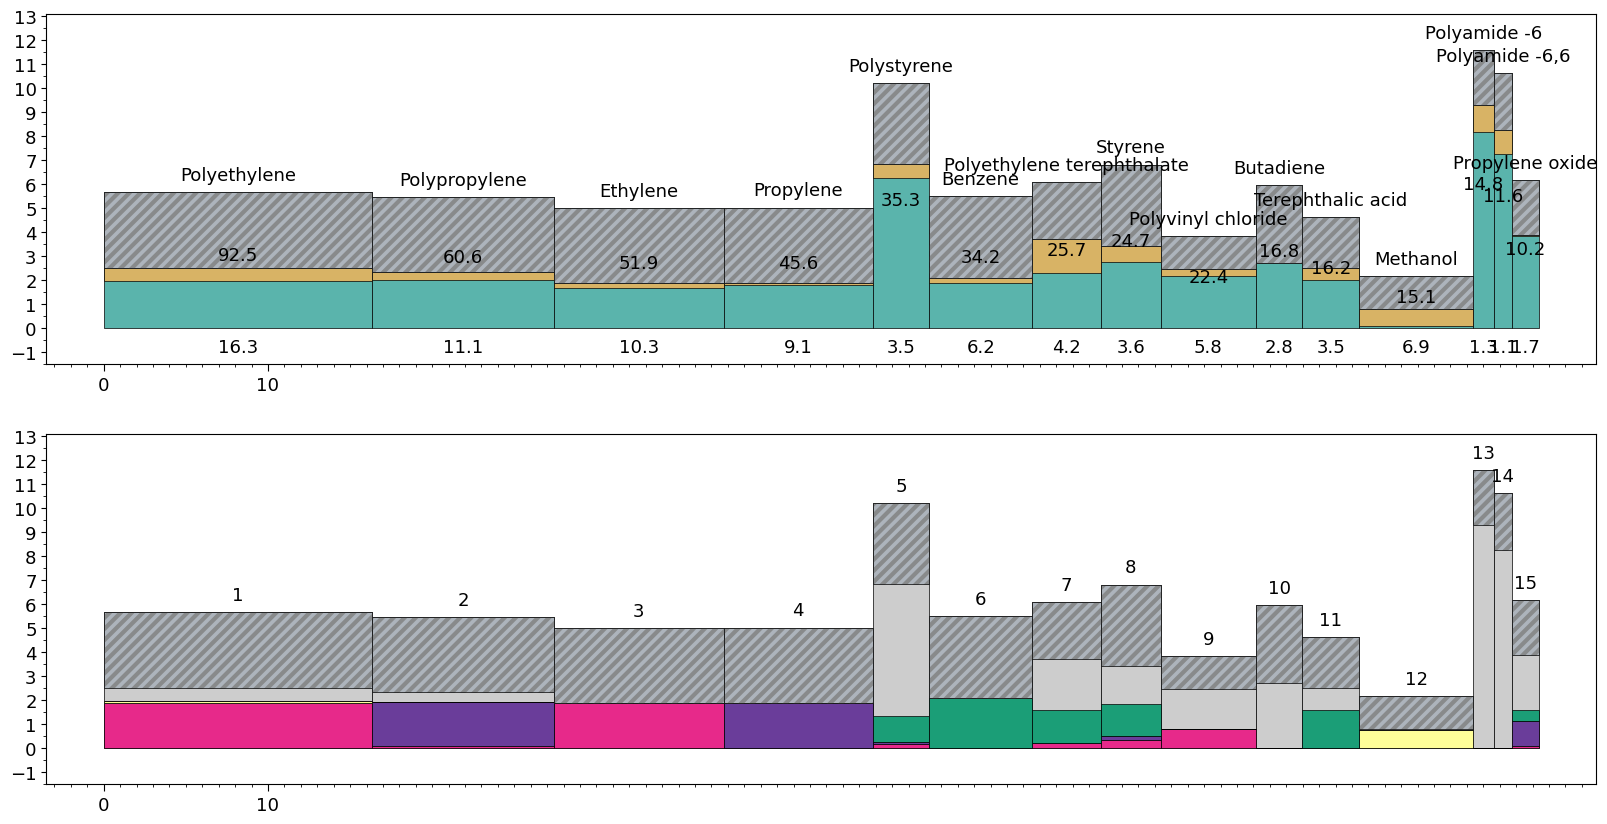

In [112]:
# color_palette = ["#9aa6b6", "#d81b60", '#1e88e5','#ffc107','#004d40','#9aa6b6']

# https://colorbrewer2.org/#type=qualitative&scheme=Paired&n=11
color_palette = {
    'local_production': "#5ab4ac",
    'import': "#d8b365",
    # 'ethylene': "#d81b60",
    # 'propylene': '#1e88e5',
    # 'methanol': '#ffc107',
    # 'btx': '#004d40',
    # 'ethylene': "#ffff99",
    # 'propylene': '#beaed4',
    # 'methanol': '#fdc086',
    # 'btx': '#7fc97f',
    'ethylene': "#e7298a",
    'propylene': '#6a3d9a',
    'methanol': '#ffff99',
    'btx': '#1b9e77',
    'production_import_rest': "#CDCDCD",
    
    # 'eol': '#9aa6b6',
    # 'eol_hatch': '#74787c',
    'eol': "#adb4bc",
    'eol_hatch': "#888A8B",
    }

ecoinvent_version = ECOINVENT_DATABASE_NAMES[1]
unit_footprint_with_eol_column_name = f"{UNIT_FOOTPRINT_WITH_EOL_COLUMN_NAME} - {ecoinvent_version}"
unit_footprint_without_eol_column_name = f"{UNIT_FOOTPRINT_WITHOUT_EOL_COLUMN_NAME} - {ecoinvent_version}"
unit_btx_column_name = f"{UNIT_BTX_FOOTPRINT_COLUMN_NAME} - {ecoinvent_version}"
total_footprint_without_eol_column_name = f"{TOTAL_FOOTPRINT_WITHOUT_EOL_COLUMN_NAME} - {ecoinvent_version}"
total_footprint_with_eol_column_name = f"{TOTAL_FOOTPRINT_WITH_EOL_COLUMN_NAME} - {ecoinvent_version}"
local_production_footprint_column_name = f"{UNIT_FOOTPRINT_LOCAL_PRODUCTION_COLUMN_NAME} - {ecoinvent_version}"
ethylene_footprint_column_name = f"ethylene - {ecoinvent_version}"
propylene_footprint_column_name = f"propylene - {ecoinvent_version}"
methanol_footprint_column_name = f"methanol - {ecoinvent_version}"

# NOTE: Sort data by decreasing order of total GHG footprint with end-of-life
hotspot_products_to_figure_df = hotspot_products_processed_df.nlargest(n=FIGURE_N_TOP_HOTSPOT_PRODUCTS, columns=[total_footprint_with_eol_column_name]).sort_values(by=[total_footprint_with_eol_column_name], ascending=False, ignore_index=True).copy()

# NOTE: Add a rank, autoincremented from 1 for the product with the highest footprint
hotspot_products_to_figure_df[OUTPUT_PRODUCT_CODE_COLUMN_NAME] = range(1, 1 + len(hotspot_products_to_figure_df))

vertical_padding = 1.5
horizontal_padding = 0.04
top_y_limit = hotspot_products_to_figure_df.nlargest(1, unit_footprint_with_eol_column_name).iloc[0][unit_footprint_with_eol_column_name] + vertical_padding

# NOTE: Calculate x axis value to position product bars horizontally in the figure
hotspot_products_processed_df['x_axis'] = float('nan')

for hotspot_product_index, hotspot_product in hotspot_products_to_figure_df.iterrows():
    if hotspot_product_index == 0:
        x_value = 0
    else:
        x_value = hotspot_products_to_figure_df.loc[hotspot_product_index-1]['x_axis'] + hotspot_products_to_figure_df.loc[hotspot_product_index-1][QUANTITY_COLUMN_NAME]

    hotspot_products_to_figure_df.at[hotspot_product_index,'x_axis'] = x_value

# NOTE: Generate figure

figure = plt.figure(figsize=(20, 10))
plt.rcParams['svg.fonttype'] = 'none'
# setting font size
plt.rcParams.update({'font.size': 13})
(ax_1, ax_2) = figure.subplots(2, 1)
#plt.tight_layout()

# NOTE: Bottom subplot

total_bars = ax_2.bar(x=hotspot_products_to_figure_df['x_axis'],
                      height=hotspot_products_to_figure_df[unit_footprint_with_eol_column_name], width=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME],
                      align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette['production_import_rest'])
# NOTE: Name bars
for bar, (idx, row) in zip(total_bars, hotspot_products_to_figure_df.iterrows()):
    gid = f"bar_totalaxes2_{row['Figure name']}_{idx}"
    bar.set_gid(gid)

ethylene_bars = ax_2.bar(x=hotspot_products_to_figure_df['x_axis'],
                        #  bottom=hotspot_products_to_figure_df[UNIT_EOL_FOOTPRINT_COLUMN_NAME],
                         height=hotspot_products_to_figure_df[ethylene_footprint_column_name],
                         width=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME], 
                         align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette['ethylene'])
# NOTE: Name bars
for bar, (idx, row) in zip(ethylene_bars, hotspot_products_to_figure_df.iterrows()):
    gid = f"bar_ethylene_{row['Figure name']}_{idx}"
    bar.set_gid(gid)

propylene_bars = ax_2.bar(x=hotspot_products_to_figure_df['x_axis'],
                          bottom=hotspot_products_to_figure_df[ethylene_footprint_column_name],
                          height=hotspot_products_to_figure_df[propylene_footprint_column_name],
                          width=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME],
                          align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette['propylene'])
# NOTE: Name bars
for bar, (idx, row) in zip(propylene_bars, hotspot_products_to_figure_df.iterrows()):
    gid = f"bar_propylene_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)

methanol_bars = ax_2.bar(x=hotspot_products_to_figure_df['x_axis'],
                         bottom=hotspot_products_to_figure_df[ethylene_footprint_column_name]+hotspot_products_to_figure_df[propylene_footprint_column_name],
                         height=hotspot_products_to_figure_df[methanol_footprint_column_name],
                         width=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME],
                         align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette['methanol'])
# NOTE: Name bars
for bar, (idx, row) in zip(methanol_bars, hotspot_products_to_figure_df.iterrows()):
    gid = f"bar_methanol_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)

btx_bars = ax_2.bar(x=hotspot_products_to_figure_df['x_axis'],
                    bottom=hotspot_products_to_figure_df[ethylene_footprint_column_name]+hotspot_products_to_figure_df[propylene_footprint_column_name]+hotspot_products_to_figure_df[methanol_footprint_column_name],
                    height=hotspot_products_to_figure_df[unit_btx_column_name],
                    width=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME],
                    align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette['btx'])
# NOTE: Name bars
for bar, (idx, row) in zip(btx_bars, hotspot_products_to_figure_df.iterrows()):
    gid = f"bar_btx_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)

eol_bars_ax_2 = ax_2.bar(x=hotspot_products_to_figure_df['x_axis'],
                    bottom=hotspot_products_to_figure_df[unit_footprint_with_eol_column_name]-hotspot_products_to_figure_df[UNIT_EOL_FOOTPRINT_COLUMN_NAME],
                    height=hotspot_products_to_figure_df[UNIT_EOL_FOOTPRINT_COLUMN_NAME],
                    width=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME],
                    align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette['eol'], hatch='///')
# NOTE: Name bars
for bar, (idx, row) in zip(eol_bars_ax_2, hotspot_products_to_figure_df.iterrows()):
    gid = f"bar_eol_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)


ax_2.set_ylim(bottom=-vertical_padding, top=top_y_limit)
ax_2.margins(x=horizontal_padding)
#ax.set_xlim(left=0, right=70000)
ax_2.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax_2.xaxis.set_major_locator(ticker.FixedLocator([0, 10]))

ax_2.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax_2.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

ax_2.tick_params(axis='x', which='major', length=5)
#ax_2.set_ymargin(1)

# NOTE: Top subplot

ax_1.set_ylim(bottom=-vertical_padding, top=top_y_limit)
ax_1.margins(x=horizontal_padding)
#ax.set_xlim(left=0, right=70000)
ax_1.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax_1.xaxis.set_major_locator(ticker.FixedLocator([0, 10]))

ax_1.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax_1.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))

ax_1.tick_params(axis='x', which='major', length=5)


total_bars_ax_1 = ax_1.bar(x=hotspot_products_to_figure_df['x_axis'], height=hotspot_products_to_figure_df[unit_footprint_with_eol_column_name],
                           width=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME], align='edge', edgecolor = 'k', linewidth = 0.5,
                           color=color_palette['local_production'])
# NOTE: Name bars
for bar, (idx, row) in zip(total_bars_ax_1, hotspot_products_to_figure_df.iterrows()):
    gid = f"bar_totalaxes1_{row[OUTPUT_PRODUCT_CODE_COLUMN_NAME]}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)

imported_production_bars = ax_1.bar(x=hotspot_products_to_figure_df['x_axis'],
                    bottom=hotspot_products_to_figure_df[local_production_footprint_column_name],
                    height=hotspot_products_to_figure_df[unit_footprint_without_eol_column_name]-hotspot_products_to_figure_df[local_production_footprint_column_name],
                    width=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME],
                    align='edge', edgecolor = 'k', linewidth = 0.5, color=color_palette['import'])
# NOTE: Name bars
for bar, (idx, row) in zip(imported_production_bars, hotspot_products_to_figure_df.iterrows()):
    gid = f"bar_local_production_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)

eol_bars_ax_1 = ax_1.bar(x=hotspot_products_to_figure_df['x_axis'],
                    bottom=hotspot_products_to_figure_df[unit_footprint_with_eol_column_name]-hotspot_products_to_figure_df[UNIT_EOL_FOOTPRINT_COLUMN_NAME],
                    height=hotspot_products_to_figure_df[UNIT_EOL_FOOTPRINT_COLUMN_NAME],
                    width=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME],
                    align='edge', edgecolor='k', linewidth = 0.5, color=color_palette['eol'], hatch='///')
# NOTE: Name bars
for bar, (idx, row) in zip(eol_bars_ax_1, hotspot_products_to_figure_df.iterrows()):
    gid = f"bar_eol_{row['Figure name']}_{idx}"  # create any naming scheme you like
    bar.set_gid(gid)

# Source : 12-08-2026 - https://stackoverflow.com/questions/38168948/how-to-decouple-hatch-and-edge-color-in-matplotlib/78749098#78749098
for bc in eol_bars_ax_1 + eol_bars_ax_2:
    bc._hatch_color = matplotlib.colors.to_rgba(color_palette['eol_hatch'])
    bc._hatch_linewidth = 3
    bc.stale = True


add_labels_total_impact(ax=ax_1, x=hotspot_products_to_figure_df['x_axis'], quantity=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME], y=hotspot_products_to_figure_df[unit_footprint_with_eol_column_name]/2,
                        amount=hotspot_products_to_figure_df[total_footprint_with_eol_column_name], id=hotspot_products_to_figure_df['Figure name'])
add_labels_quantities(ax=ax_1, x=hotspot_products_to_figure_df['x_axis'], quantity=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME],
                      amount=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME], id=hotspot_products_to_figure_df['Figure name'])
#add_labels_unit_impact(ax=ax_2, x=output_table['x_axis'], quantity=output_table['Quantity'], y=output_table['unit impact'], amount=output_table['unit impact'], id=output_table['PRCCODE (Labels)'])

add_labels_code(ax=ax_2, x=hotspot_products_to_figure_df['x_axis'], quantity=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME], y=hotspot_products_to_figure_df[unit_footprint_with_eol_column_name],
              value=hotspot_products_to_figure_df[OUTPUT_PRODUCT_CODE_COLUMN_NAME], id=hotspot_products_to_figure_df['Figure name'])

add_labels_name(ax=ax_1, x=hotspot_products_to_figure_df['x_axis'], quantity=hotspot_products_to_figure_df[QUANTITY_COLUMN_NAME], y=hotspot_products_to_figure_df[unit_footprint_with_eol_column_name],
              name=hotspot_products_to_figure_df['Figure name'], id=hotspot_products_to_figure_df['Figure name'])

# NOTE: Save figure to file
plt.savefig(f"output/figure top {FIGURE_N_TOP_HOTSPOT_PRODUCTS} - {ecoinvent_version}.svg")

plt.show

## Figure post-treatment

In [1]:
import xml.etree.ElementTree as ET

In [2]:
# Source : 27-10-2025 - https://chatgpt.com/c/68ff4810-10a4-832e-b90a-33369191ba4c
# 3) Parse SVG and create a group wrapping the bars
# Note: the SVG has a default namespace; we handle it explicitly.
SVG_NS = "http://www.w3.org/2000/svg"
NS = {"svg": SVG_NS}
ET.register_namespace("", SVG_NS)  # preserve default namespace on write

tree = ET.parse('output/figure.svg')

In [ ]:
def postProcessSVG(root, axes_list=['axes_1', 'axes_2']):
    for axes in axes_list:
        axes_element = root.find(f".//svg:g[@id='{axes}']", NS)

        element_list = [e.get('id') for e in axes_element.findall(".//svg:g[@id]", NS)]
        patterns = []
        r = re.compile("^(.*?_.*?)_.*")

        for el in element_list:
            match = r.match(el)
            if match and match.group(1):
                pattern_group = match.group(1)
                patterns.append(pattern_group)

        patterns = list(reversed(list(set(patterns))))

        for pattern in patterns:
        
            # Find all elements that are bar paths/rects by id pattern "bar_..."
            # They might be <path> or <rect> depending on style/backend
            bar_elems = []
            for elem in axes_element.findall(".//svg:g", NS):
                eid = elem.get("id")
                if eid and eid.startswith(pattern):
                    bar_elems.append(elem)
            
            if not bar_elems:
                raise RuntimeError("No elements found with id starting 'bar_'. \
                                   Check the GIDs on bars and the SVG content.")
            else:
                bar_elems

            # Find where to insert the group: common place is as a child of the main <g> that contains axes.
            # We'll insert the new group as a child of the root SVG for simplicity.
            svg_group_element = ET.Element(f"{{{SVG_NS}}}g", {"id": f"group_{pattern}"})

            # Move each bar element into the new group.
            # Removing from the original parent requires finding that parent.
            def find_parent(root_node, child):
                for p in root_node.iter():
                    for c in p:
                        if c is child:
                            return p
                return None

            for e in bar_elems:
                parent = axes_element.find(f".//svg:g[@id='{e.get('id')}']/..", NS)
                # parent = find_parent(root, e)
                if parent is None:
                    continue
                parent.remove(e)
                svg_group_element.append(e)

            # Insert group into root (or into a suitable parent if you prefer)
            axes_element.append(svg_group_element)

In [4]:
# Source : 27-10-2025 - https://chatgpt.com/c/68ff4810-10a4-832e-b90a-33369191ba4c
def flatten(node):
    """Remove <g> elements that only contain a single child and no attributes."""
    for child in list(node):
        flatten(child)
    # If a <g> has only one child and no attributes other than id, flatten it
    for g in list(node.findall(f"{{{SVG_NS}}}g")):
        children = list(g)
        attrs = {k: v for k, v in g.attrib.items() if k != "id"}
        if len(children) == 1 and not attrs:
            child = children[0]
            if "id" in g.attrib and "id" not in child.attrib:
                child.attrib["id"] = g.attrib["id"]
            node.insert(list(node).index(g), child)
            node.remove(g)

In [5]:
root = tree.getroot()
postProcessSVG(root)
flatten(root)

In [6]:
# 4) Write out modified SVG
export_tree = ET.ElementTree(root)
export_tree.write("output/grouped_bars.svg", encoding="utf-8", xml_declaration=True)

print("Saved grouped_bars.svg with <g id='group_series1'> containing bar_* elements.")

Saved grouped_bars.svg with <g id='group_series1'> containing bar_* elements.
